In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Inputs (X) and Labels (y)
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, input_dim=2, activation='relu'), # Hidden Layer
    tf.keras.layers.Dense(8, input_dim=4, activation='relu')
    tf.keras.layers.Dense(1, activation='sigmoid')           # Output Layer
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1527043178.py, line 3)

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, input_dim=2, activation='relu'), # Layer 1 (Hidden)
    tf.keras.layers.Dense(8, activation='relu'),              # Layer 2 (Hidden) - No input_dim needed!
    tf.keras.layers.Dense(1, activation='sigmoid')           # Layer 3 (Output)
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(X, y, epochs=500, verbose=0) # verbose=0 keeps it quiet
print("Training Complete!")

Training Complete!


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


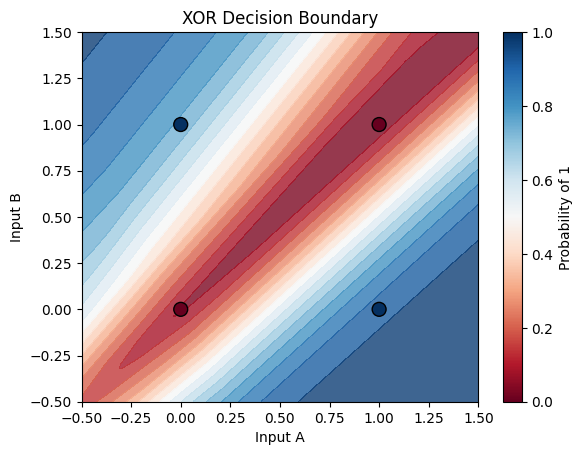

In [20]:
# Create a grid of points to see the "decision zones"
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid).reshape(xx.shape)

# Plotting
plt.contourf(xx, yy, preds, levels=20, cmap='RdBu', alpha=0.8)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), s=100, edgecolors='k', cmap='RdBu')
plt.title("XOR Decision Boundary")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.colorbar(label="Probability of 1")
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


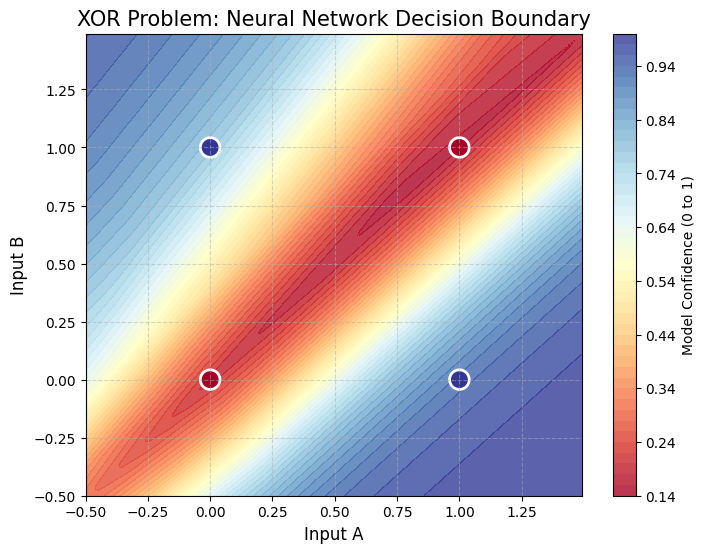

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    # 1. Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01  # step size in the mesh
    
    # 2. Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # 3. Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 4. Plot the contour and training examples
    plt.figure(figsize=(8, 6))
    # 'RdYlBu' is Red-Yellow-Blue, very easy for examiners to see
    plt.contourf(xx, yy, Z, levels=50, cmap="RdYlBu", alpha=0.8)
    plt.colorbar(label="Model Confidence (0 to 1)")
    
    # Plot the original 4 XOR points with high contrast
    # c=y tells it to color based on 0 or 1
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=200, 
                edgecolors='white', linewidth=2, cmap="RdYlBu")
    
    plt.title("XOR Problem: Neural Network Decision Boundary", fontsize=15)
    plt.xlabel("Input A", fontsize=12)
    plt.ylabel("Input B", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Call the function
plot_decision_boundary(model, X, y)